In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model 
from functions import * 
pd.set_option('display.precision', 18)

In [3]:
be_1po = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_1Po.csv')
be_1po = be_1po.drop(columns = ['SO1', 'SO2'])
be_1po = be_1po.rename(columns= {'Basis Size': 'basis size'})
be_1po_inf = be_1po.loc[be_1po['basis size'] == max(be_1po['basis size'])]
be_1po_init = be_1po.iloc[:-1]

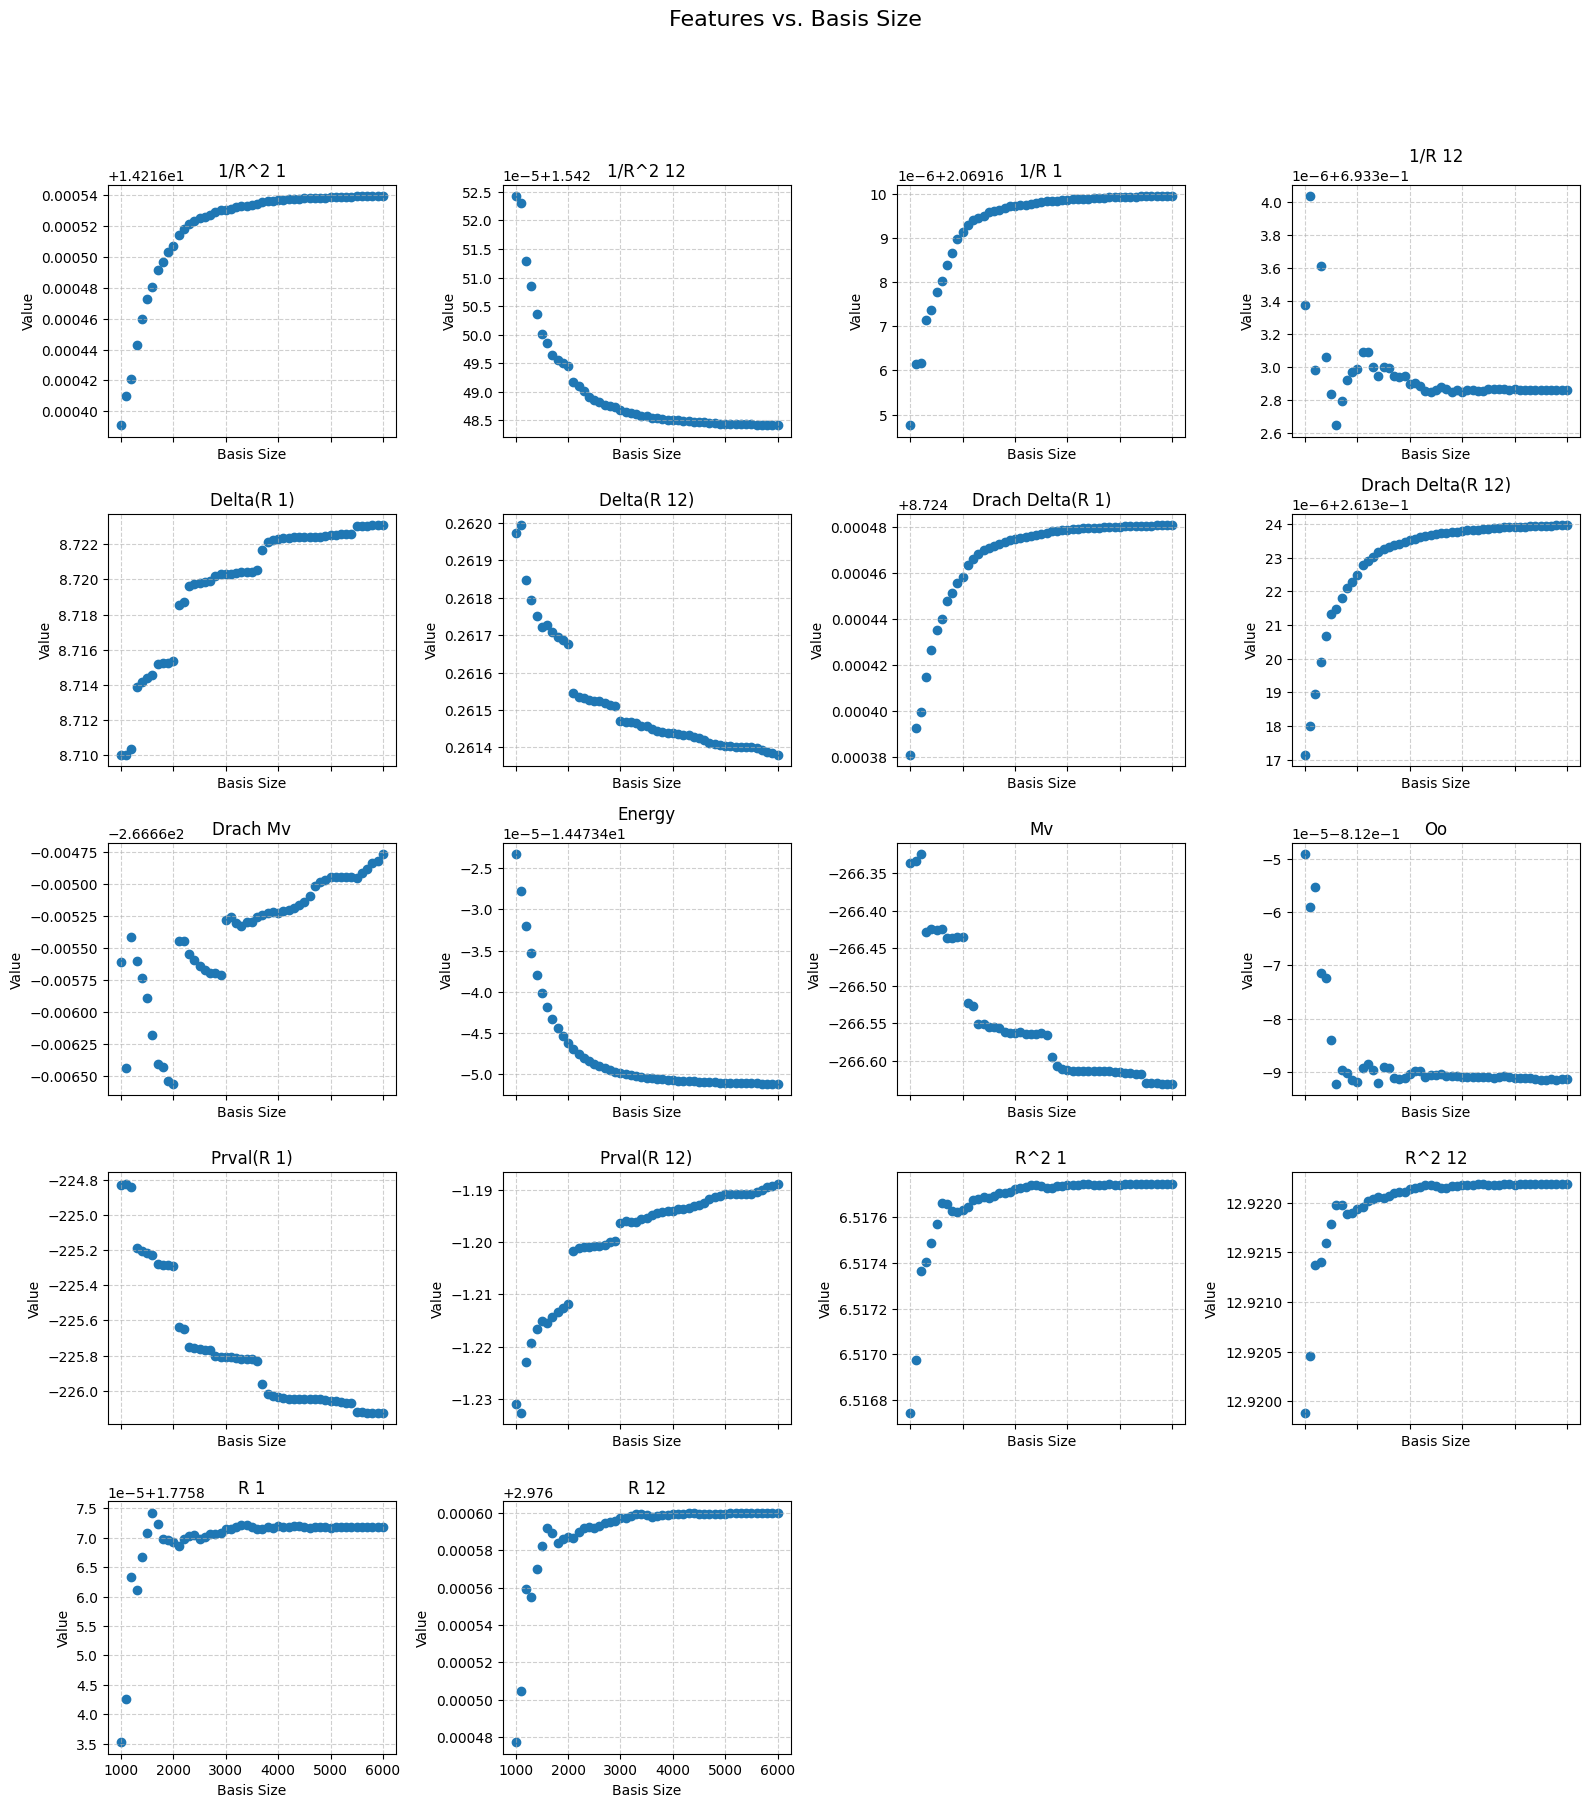

In [5]:
graph(be_1po_init)

In [6]:
from scipy.optimize import least_squares, lsq_linear
from numpy.linalg import lstsq, inv, pinv

class VarProIRLS:
    def __init__(self, df, x_col, y_col, b_init=None, fixed_horizon=None):
        self.raw_x = df[x_col].values.astype(float)
        self.raw_y = df[y_col].values.astype(float)
        self.x_col = x_col
        self.y_col = y_col
        
        idx = np.argsort(self.raw_x)
        self.raw_x = self.raw_x[idx]
        self.raw_y = self.raw_y[idx]

        self.x_min = self.raw_x.min()
        self.x_max = self.raw_x.max()
        self.range_x = self.x_max - self.x_min
        if self.range_x == 0: self.range_x = 1.0
        
        self.is_increasing = self.raw_y[-1] > self.raw_y[0]
        
        # Use fixed horizon if provided, otherwise calculate
        if fixed_horizon is not None:
            self.c_min, self.c_max = fixed_horizon
        else:
            self.c_min, self.c_max = self._calculate_horizon()
        
        # Store override init (e.g. for warm starts), but don't calculate yet
        self.override_b_init = b_init
        self.b_init = 1.0
        self.results = {}

    def _calculate_horizon(self):
        # Need enough points to establish a history
        if len(self.raw_y) < 4: 
            return -np.inf, np.inf
        
        # 1. Compute all step sizes (absolute changes)
        dy = np.abs(np.diff(self.raw_y))
        
        # 2. Compute ratios of consecutive steps across the whole dataset
        valid_denoms = dy[:-1] > 1e-15
        if np.sum(valid_denoms) < 1:
            return -np.inf, np.inf
            
        ratios = dy[1:][valid_denoms] / dy[:-1][valid_denoms]
        
        # 3. Identify "Physical" Convergence Ratios from history
        valid_ratios = ratios[(ratios > 0.0) & (ratios < 0.99)]
        
        if len(valid_ratios) > 0:
            R_est = np.max(valid_ratios)
        else:
            R_est = 0.90

        # 4. Geometric Projection using data-driven R
        last_step = dy[-1]
        R_est = min(R_est, 0.95)
        
        y_tail = self.raw_y[-3:]
        dy_tail = np.abs(np.diff(y_tail))
        if dy_tail[0] > 1e-15:
            local_R = dy_tail[1] / dy_tail[0]
            if local_R >= 0.95: 
                horizon = last_step * 3.0
            else:
                horizon = last_step * (R_est / (1.0 - R_est))
        else:
             horizon = last_step * (R_est / (1.0 - R_est))

        min_horizon = max(1e-8, abs(self.raw_y[-1]) * 1e-5)
        horizon = max(horizon, min_horizon)

        if self.is_increasing:
            c_min = self.raw_y[-1]
            c_max = self.raw_y[-1] + horizon
        else:
            c_min = self.raw_y[-1] - horizon
            c_max = self.raw_y[-1]
            
        if c_max <= c_min + min_horizon:
            if self.is_increasing: c_max = c_min + min_horizon
            else: c_min = c_max - min_horizon

        return c_min, c_max

    def _setup_model(self, model_type):
        self.model_type = model_type
        if self.model_type in ['power_law', 'sqrt_exponential']:
            safe_x = np.maximum(self.raw_x, self.x_max * 1e-6)
            self.t_scaled = safe_x / self.x_max
        else:
            self.t_scaled = (self.raw_x - self.x_min) / self.range_x
            
        if self.override_b_init is not None:
            self.b_init = self.override_b_init
        else:
            self.b_init = self._grid_search_initialization()

    def _grid_search_initialization(self):
        grid_B = np.linspace(0.01, 100.0, 10000) 
        best_ssr = np.inf
        best_B = 1.0
        
        if self.is_increasing:
            lb = [self.c_min, -np.inf]
            ub = [self.c_max, 0]
        else:
            lb = [self.c_min, 0]
            ub = [self.c_max, np.inf]
        
        for b_val in grid_B:
            phi = self._compute_basis(b_val, self.t_scaled)
            
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.inf
            
            if ssr < best_ssr:
                best_ssr = ssr
                best_B = b_val
                
        return best_B

    def _compute_basis(self, B, t):
        phi = np.zeros((len(t), 2))
        phi[:, 0] = 1.0
        if self.model_type == 'exponential':
            phi[:, 1] = np.exp(-B * t)
        elif self.model_type == 'sqrt_exponential':
            phi[:, 1] = np.exp(-B * np.sqrt(t))
        elif self.model_type == 'power_law':
            phi[:, 1] = np.power(t, -B)
        return phi

    def _compute_model_weights(self, B, t):
        if self.model_type == 'exponential':
            w = np.exp(B * t)
        elif self.model_type == 'sqrt_exponential':
            w = np.exp(B * np.sqrt(t))
        elif self.model_type == 'power_law':
            t_safe = np.maximum(t, 1e-12)
            w = np.power(t_safe, B)
        
        # Square the weights to aggressively prioritize the tail
        w = w ** 2
        
        w = np.nan_to_num(w, nan=1.0, posinf=np.finfo(float).max, neginf=0.0)
        return w

    def _solve_varpro_step(self, weights, start_b=None):
        y_w = self.raw_y * np.sqrt(weights)
        if start_b is None: start_b = self.b_init
        
        if self.is_increasing:
            lb = [self.c_min, -np.inf]
            ub = [self.c_max, 0]
        else:
            lb = [self.c_min, 0]
            ub = [self.c_max, np.inf]

        def residual_func(alpha_curr):
            phi = self._compute_basis(alpha_curr[0], self.t_scaled)
            phi_w = phi * np.sqrt(weights)[:, np.newaxis]
            res_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
            y_model = np.dot(phi, res_lin.x)
            return (self.raw_y - y_model) * np.sqrt(weights)

        res_opt = least_squares(residual_func, x0=[start_b], bounds=(1e-6, np.inf), 
                                method='trf', loss='soft_l1')
        
        best_B = res_opt.x[0]
        phi = self._compute_basis(best_B, self.t_scaled)
        phi_w = phi * np.sqrt(weights)[:, np.newaxis]
        final_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
        
        return best_B, final_lin.x[0], final_lin.x[1]

    def fit_irls(self, max_iter=100, tol=1e-8, damping=0.5, models=None, verbose=True, compute_uq=True):
        if models is None:
            models = ['exponential', 'sqrt_exponential', 'power_law']
        
        for model in models:
            self._setup_model(model)
            if verbose:
                print(f"\n--- Fitting Model: {self.model_type} ---")
                print(f"{'Iter':<5} | {'B (Decay)':<12} | {'C (Asymptote)':<15} | {'Weight Ratio':<25}")
                print("-" * 65)

            current_weights = np.ones(len(self.raw_x))
            prev_C = np.inf
            current_B_guess = self.b_init
            
            final_B, final_C, final_A = 0, 0, 0

            for k in range(max_iter):
                B, C, A = self._solve_varpro_step(current_weights, start_b=current_B_guess)
                current_B_guess = B
                final_B, final_C, final_A = B, C, A

                if abs(C - prev_C) < tol and k > 0:
                    if verbose:
                        print("-" * 65)
                        print(f"Converged at iteration {k}")
                    break
                prev_C = C

                new_weights = self._compute_model_weights(B, self.t_scaled)
                new_weights /= np.mean(new_weights)
                new_weights = np.clip(new_weights, 0, 1e6)
                
                current_weights = (1 - damping) * current_weights + damping * new_weights
                
                if verbose:
                    w_ratio = current_weights[-1] / (current_weights[0] + 1e-12)
                    print(f"{k:<5} | {B:<12.6f} | {C:<15.6f} | {w_ratio:<25.2f}")

            phi = self._compute_basis(final_B, self.t_scaled)
            y_pred = final_C + final_A * phi[:, 1]
            ssr = np.sum((self.raw_y - y_pred)**2)
            
            dof = max(1, len(self.raw_y) - 3)
            sigma_noise = np.sqrt(ssr / dof)

            self.results[model] = {
                'B': final_B, 'C': final_C, 'A': final_A, 
                'ssr': ssr, 't_scaled': self.t_scaled.copy(),
                'sigma_noise': sigma_noise,
                'y_pred': y_pred,
                'final_weights': current_weights # Store weights for UQ
            }
        
        if compute_uq and len(self.results) > 0:
            self.estimate_monte_carlo_uncertainty()
            
        return self.results

    def estimate_monte_carlo_uncertainty(self, n_samples=30):
        # Capture the original horizon from the REAL data
        real_c_min = self.c_min
        real_c_max = self.c_max
        
        # Inflate horizon slightly for MC to allow for noise exploration
        range_c = real_c_max - real_c_min
        mc_c_min = real_c_min - (range_c * 0.5) 
        mc_c_max = real_c_max + (range_c * 0.5)
        
        for model_name, res in self.results.items():
            y_pred = res['y_pred']
            sigma_noise = res['sigma_noise']
            warm_start_b = res['B']
            final_weights = res['final_weights'] # Retrieve weights from fit
            
            mc_Cs = []
            
            # Weighted Noise Scaling Factor
            # Noise should be proportional to 1/sqrt(weight)
            # If weight is high (tail), noise is low.
            # Normalize weights so max weight corresponds to minimum noise scaling
            normalized_weights = final_weights / np.max(final_weights)
            noise_scale_factors = 1.0 / np.sqrt(normalized_weights + 1e-6)
            
            for i in range(n_samples):
                # Generate heteroscedastic noise
                base_noise = np.random.normal(0, sigma_noise, size=len(y_pred))
                weighted_noise = base_noise * noise_scale_factors
                
                y_synthetic = y_pred + weighted_noise
                
                sub_df = pd.DataFrame({self.x_col: self.raw_x, self.y_col: y_synthetic})
                
                # Pass warm start B for the correct model type
                sub_solver = VarProIRLS(sub_df, self.x_col, self.y_col, 
                                      b_init=warm_start_b, 
                                      fixed_horizon=(mc_c_min, mc_c_max))
                
                sub_solver.fit_irls(models=[model_name], verbose=False, compute_uq=False)
                
                if model_name in sub_solver.results:
                    mc_Cs.append(sub_solver.results[model_name]['C'])
            
            q75, q25 = np.percentile(mc_Cs, [75 ,25])
            sigma_robust = (q75 - q25) / 1.35
            
            if sigma_robust < 1e-12:
                sigma_robust = np.std(mc_Cs)
                
            self.results[model_name]['sigma_mc'] = sigma_robust

    def plot(self, truth_val=None):
        if not self.results: return
        
        plt.figure(figsize=(12, 7))
        plt.plot(self.raw_x, self.raw_y, 'ko', label='Data', zorder=5, markersize=6)
        
        colors = {'exponential': 'blue', 'sqrt_exponential': 'orange', 'power_law': 'green'}
        labels = {'exponential': 'Exp($e^{-Bx}$)', 'sqrt_exponential': 'SqrtExp($e^{-B\\sqrt{x}}$)', 'power_law': 'Power($x^{-B}$)'}
        
        print("\n" + "="*80)
        print(f"{'Model':<20} | {'C (Asymptote)':<15} | {'MC Uncertainty':<20} | {'Diff from Truth'}")
        print("="*80)

        for model, res in self.results.items():
            C = res['C']
            sigma = res.get('sigma_mc', 0.0)
            
            diff_str = "-"
            if truth_val is not None:
                diff_str = f"{abs(C - truth_val):.2e}"
            
            print(f"{model:<20} | {C:<15.9f} | {sigma:<20.9f} | {diff_str}")
            
            x_plot = np.linspace(self.x_min, self.x_max * 1.5, 200)
            
            if model in ['power_law', 'sqrt_exponential']:
                t_plot = x_plot / self.x_max
            else:
                t_plot = (x_plot - self.x_min) / self.range_x
            
            self.model_type = model
            phi_plot = self._compute_basis(res['B'], t_plot)
            y_plot = C + res['A'] * phi_plot[:, 1]
            
            plt.plot(x_plot, y_plot, '-', color=colors[model], linewidth=2, alpha=0.8, label=f"{labels[model]}")
            
            plt.fill_between([self.x_min, self.x_max * 1.5], 
                             C - sigma, C + sigma, 
                             color=colors[model], alpha=0.1)
            
            plt.axhline(C, color=colors[model], linestyle='--', alpha=0.3)

        if truth_val is not None: 
            plt.axhline(truth_val, color='r', linestyle=':', linewidth=2, label=f'Truth ({truth_val})')
            
        plt.title(f"{self.y_col}")
        plt.xlabel("Basis Size")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


--- Fitting Model: exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 25.630000    | 1.775872        | 33.71                    
-----------------------------------------------------------------
Converged at iteration 1

--- Fitting Model: sqrt_exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 26.710000    | 1.775872        | 19.60                    
-----------------------------------------------------------------
Converged at iteration 1

--- Fitting Model: power_law ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 5.800000     | 1.775872        | 10.66                    
-----------------------------------------------------------------
Converged at iteration 1

Model          

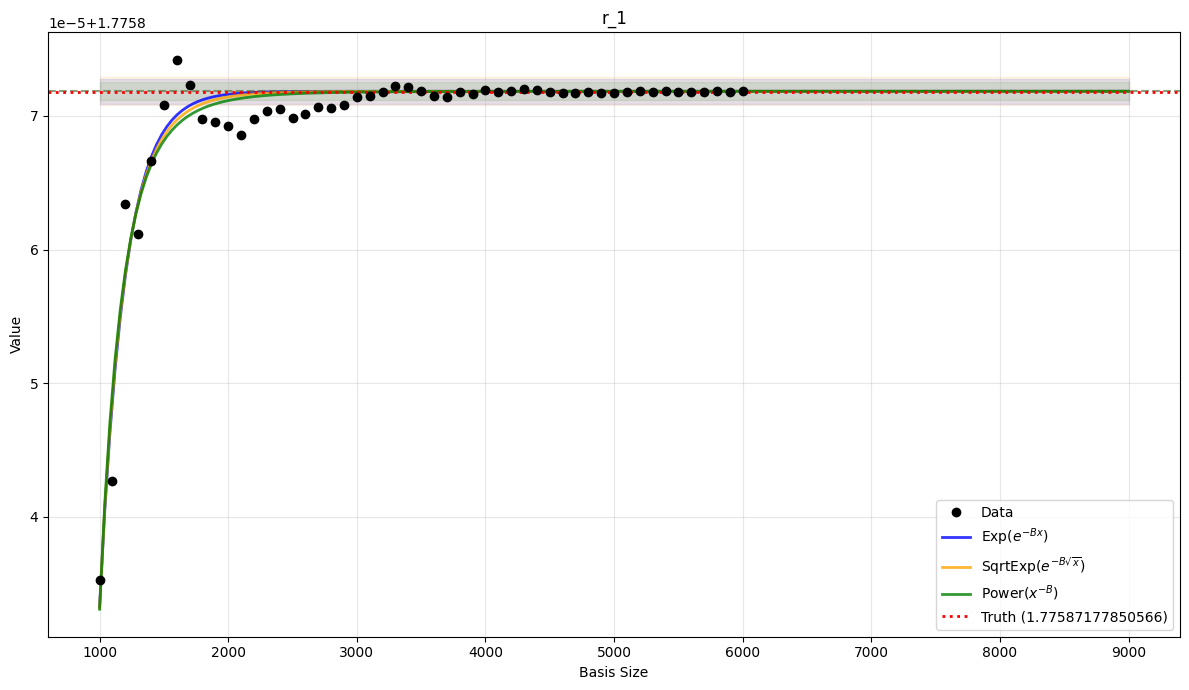

In [13]:
solver = VarProIRLS(be_1po_init, 'basis size', 'r_1')
solver.fit_irls()
solver.plot(truth_val =1.775871778505659915)

In [7]:
be_1po_inf

,basis size,Energy,MV,drach_MV,OO,1/r^2_1,1/r^2_12,1/r_1,1/r_12,r_1,r_12,r^2_1,r^2_12,delta(r_1),delta(r_12),drach_delta(r_1),drach_delta(r_12),prval(r_1),prval(r_12)
60,16400,-14.473451386869200519,-266.659088807117996112,-266.664462793425002474,-0.812091476559140046,14.216540761971700135,1.542483736797960026,2.069169995852650157,0.693302859821317008,1.775871778505659915,2.976600188092250132,6.517748468239560111,12.922195769590199887,8.724265747607580224,0.261343940528712015,8.724481440729169535,0.261324032380949978,-226.280220458874993028,-1.185257894829250036
